# Athens Airbnb Prices Exploratory Data Analysis

This analysis project seeks to explore the pricing trends of Airbnb listings in Athens.

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [126]:
athens_data = pd.read_csv('listings.csv') 
print(athens_data.shape)

(15584, 79)


In [127]:
athens_data.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

## Extracting relevant columns that are going to be used in the analysis
As of this moment we will mainly focus on the Price, Neighbourhood, Number of Bedrooms, Room Type, Yearly Availability and Number of Reviews    
left on the Airbnb listings in the city of Athens, Greece.

In [131]:
cols = ['price', 'neighbourhood_cleansed', 'bedrooms', 'room_type', 'availability_365', 'review_scores_rating']

athens_data = athens_data[cols]
print(athens_data.head())

     price  neighbourhood_cleansed  bedrooms        room_type  \
0      NaN             ΑΜΠΕΛΟΚΗΠΟΙ       1.0  Entire home/apt   
1   $45.00          ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ       2.0  Entire home/apt   
2  $160.00  ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ       3.0  Entire home/apt   
3   $50.00                  ΣΤΑΔΙΟ       1.0  Entire home/apt   
4      NaN                ΠΑΓΚΡΑΤΙ       1.0  Entire home/apt   

   availability_365  review_scores_rating  
0                 0                  4.86  
1               269                  4.76  
2                72                  4.68  
3                54                  4.97  
4                 0                  4.68  


### Data Cleaning 

In [134]:
#Dropping missing values
athens_data = athens_data.dropna()

#Converting $ (which python sees as string data) into float 
athens_data['price'] = athens_data['price'].replace('[$,]', '', regex=True).astype(float)

In [136]:
print(athens_data.shape)
print(athens_data.head())

(12402, 6)
   price    neighbourhood_cleansed  bedrooms        room_type  \
1   45.0            ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ       2.0  Entire home/apt   
2  160.0    ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ       3.0  Entire home/apt   
3   50.0                    ΣΤΑΔΙΟ       1.0  Entire home/apt   
5   70.0  ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ       1.0  Entire home/apt   
6   57.0                  ΑΚΡΟΠΟΛΗ       1.0  Entire home/apt   

   availability_365  review_scores_rating  
1               269                  4.76  
2                72                  4.68  
3                54                  4.97  
5               347                  4.73  
6                 0                  4.77  


### Exploring Basic Statistics of the dataset

In [139]:
print(athens_data.describe())

              price      bedrooms  availability_365  review_scores_rating
count  12402.000000  12402.000000      12402.000000          12402.000000
mean     109.910579      1.413804        258.141509              4.772567
std      432.627553      0.862274        105.179494              0.361351
min       10.000000      0.000000          0.000000              1.000000
25%       53.000000      1.000000        187.000000              4.710000
50%       75.000000      1.000000        306.000000              4.870000
75%      111.000000      2.000000        341.000000              4.980000
max    38000.000000     14.000000        365.000000              5.000000


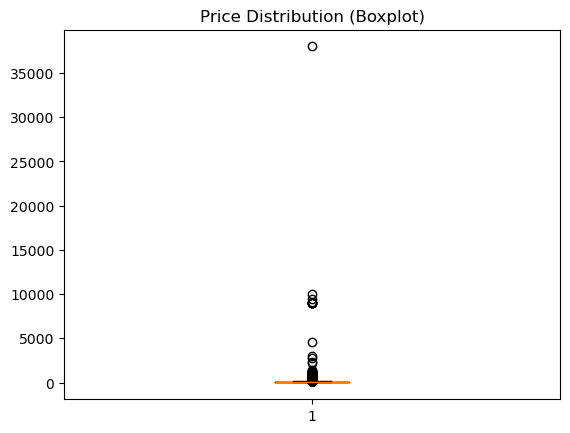

In [141]:
#Boxplot showing the price distribution
plt.figure()
plt.boxplot(athens_data['price'])
plt.title("Price Distribution (Boxplot)")
plt.show()

### Outliers
The descriptive statistics, as well as the boxplot show outlier values, with the most prominent outlier being the $38,000 listing.    
This can be attributed to high-end listings or errors when inputting the data.

For this reason let us explore more on the topic and see the full profile of the top 10 highest outliers.

In [144]:
#Detecting the major outliers in pricing
athens_data.sort_values("price", ascending=False).head(10)

,price,neighbourhood_cleansed,bedrooms,room_type,availability_365,review_scores_rating
9466,38000.0,ΚΕΡΑΜΕΙΚΟΣ,2.0,Entire home/apt,11,4.81
48,10000.0,ΚΕΡΑΜΕΙΚΟΣ,2.0,Entire home/apt,25,4.88
11221,9429.0,ΕΛΛΗΝΟΡΩΣΩΝ,2.0,Entire home/apt,364,4.33
7310,9143.0,ΕΛΛΗΝΟΡΩΣΩΝ,1.0,Entire home/apt,365,5.00
8416,9000.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,1.0,Entire home/apt,364,4.00
11149,9000.0,ΠΑΤΗΣΙΑ,2.0,Entire home/apt,364,4.50
7949,9000.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,1.0,Entire home/apt,364,4.33
7948,9000.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,1.0,Entire home/apt,364,3.00
7947,9000.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,1.0,Entire home/apt,364,4.40
7946,9000.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,1.0,Entire home/apt,364,4.43


## Exploring Average Prices per Neighbourhood and Room Type 
In this segment of the code we will be analysing the Average Price per Athens Neighbourhood, as well as the Average Price per Room Type.     
These findings will also be visualised through the help of barchars for better understanding of the data. 

In [147]:
#Average Price per Neighbourhood
avg_nbhd_price = athens_data.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

print(avg_nbhd_price.sort_values(ascending=False))

neighbourhood_cleansed
ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ                      709.558824
ΕΛΛΗΝΟΡΩΣΩΝ                         376.500000
ΚΕΡΑΜΕΙΚΟΣ                          242.144022
ΖΑΠΠΕΙΟ                             167.666667
ΑΚΡΟΠΟΛΗ                            148.973171
ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ              133.916837
ΚΟΛΩΝΑΚΙ                            130.618557
ΒΟΤΑΝΙΚΟΣ                           127.250000
ΡΗΓΙΛΛΗΣ                            125.400000
ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ                 121.008203
ΠΑΤΗΣΙΑ                             115.340741
ΘΗΣΕΙΟ                              114.629921
ΓΚΑΖΙ                               112.534653
ΣΤΑΔΙΟ                              111.455882
ΛΥΚΑΒΗΤΤΟΣ                           98.646667
ΙΛΙΣΙΑ                               98.642487
1Ο ΝΕΚΡΟΤΑΦΕΙΟ                       89.236842
ΝΕΟΣ ΚΟΣΜΟΣ                          86.878199
ΠΕΤΡΑΛΩΝΑ                            86.687500
ΠΑΓΚΡΑΤΙ                             84.736347
ΓΟΥΒΑ                                

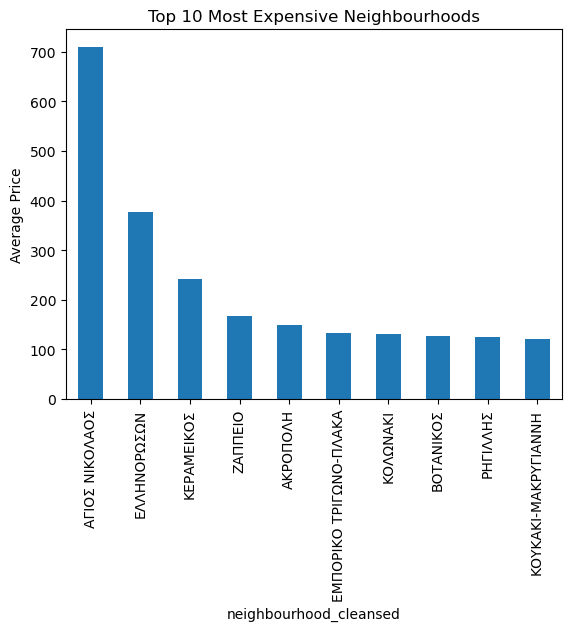

In [149]:
#Bar-char of the Top 10 most expensive neighbourhoods in Athens
plt.figure()
avg_nbhd_price.head(10).plot(kind='bar')
plt.title("Top 10 Most Expensive Neighbourhoods")
plt.ylabel("Average Price")
plt.show()

#### On Average "Agios Nikolaos" is the most expensive Athenian Neighbourhood when it comes to Airbnb listings. 

In [152]:
#Average Price per Room Type
avg_room_price = athens_data.groupby('room_type')['price'].mean() 
print(avg_room_price)

room_type
Entire home/apt    112.007248
Hotel room         156.230769
Private room        69.818781
Shared room         36.321429
Name: price, dtype: float64


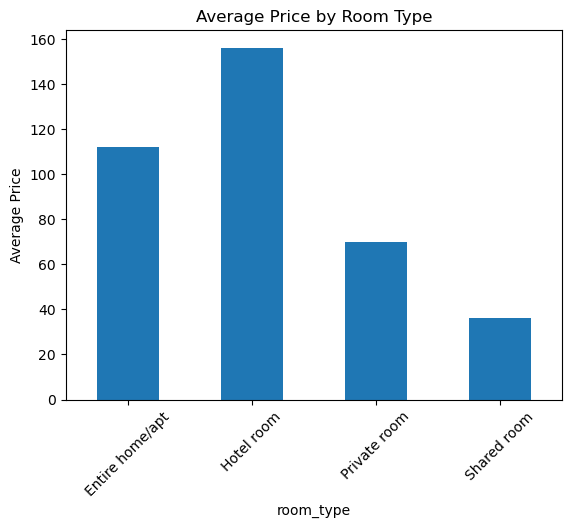

In [154]:
#Bar-char comparing price by room type
plt.figure()
avg_room_price.plot(kind='bar')
plt.title("Average Price by Room Type")
plt.ylabel("Average Price")
plt.xticks(rotation = 45)
plt.show()

#### On Average, Hotel Rooms are the most expensive, while Shared Rooms are the cheapest in Athens

### Correlation Matrix

In [158]:
#Correlation between price, number of bedrooms, number of reviews and availability in a year
corr = athens_data[['price', 'bedrooms', 'availability_365', 'review_scores_rating']].corr()
print("\nCorrelation Matrix:")
print(corr)


Correlation Matrix:
                         price  bedrooms  availability_365  \
price                 1.000000  0.108801          0.005950   
bedrooms              0.108801  1.000000         -0.013660   
availability_365      0.005950 -0.013660          1.000000   
review_scores_rating  0.004445  0.031514         -0.017524   

                      review_scores_rating  
price                             0.004445  
bedrooms                          0.031514  
availability_365                 -0.017524  
review_scores_rating              1.000000  


#### The price is positively correlated to the number of bedrooms in the listings.